# 🧹 Credit Risk — Modelling

## 📌 Overview

- In this notebook we will perform the final modelling, if you are interested in all the tests that have been performed before check out the 'credit_tests' notebook.
- We will use logistic regression as the baseline model.


## 📚 Libraries

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## 📂 Load Dataset

In [16]:
path = Path("Data")
df = pd.read_csv(path / "german_credit_cleaned.csv")

## 🔎 Train - Test Split

In [17]:
# Train Test Split
X = df.drop(columns=['SeriousDlqin2yrs'])
X = pd.get_dummies(X, drop_first=True)
y = df['SeriousDlqin2yrs']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

## 🎯 Baseline Model: Logistic Regression

Before applying advanced tuning techniques or more complex machine learning models, a baseline Logistic Regression model was developed to establish an initial performance benchmark for the credit default classification task. This first approach was implemented using the model’s default parameters, providing a simple and interpretable reference point to evaluate how subsequent optimization and more sophisticated algorithms improve predictive performance.

In [18]:
# Baseline Model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)
y_pred_reg = model.predict(X_test)
print("Regular Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_reg))

Regular Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     27996
           1       0.60      0.18      0.28      1948

    accuracy                           0.94     29944
   macro avg       0.77      0.59      0.62     29944
weighted avg       0.92      0.94      0.92     29944



As we can observe from the results shown, this model is not performing very well. It is able to recognize the majority class but struggles a lot with the other one. The precision of the model is quite hiogh, but it is highly skewed. Most importantly, this model is not ready for production due to his extremely low recall, in credit risk such a low value would result in a high monetary loss.

**Weight Adjustments** 

To address the class imbalance in the dataset, we adjust the model by applying the class_weight parameter. Specifically, we use the observed imbalance ratio of 1:14 to assign higher importance to the minority class during training. This helps the model avoid bias toward the majority class and improves its ability to correctly identify underrepresented instances. By incorporating class weights, we aim to achieve a more balanced performance across both classes without modifying the original data distribution.

In [19]:
# Weighted Logistic Regression
weights = {0: 1, 1: 14}
weighted_lr_model = LogisticRegression(random_state=42, class_weight=weights, max_iter=1000)
weighted_lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{0: 1, 1: 14}"
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
y_pred_log = weighted_lr_model.predict(X_test)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     27996
           1       0.22      0.71      0.34      1948

    accuracy                           0.82     29944
   macro avg       0.60      0.77      0.62     29944
weighted avg       0.93      0.82      0.86     29944



The results now are much better, we have a higher recall value, but we lost a lot of precision in the trade. Even though this model could be acceptable in some very niche scenarios it is not considered an optimal value for this particular project standards.

### Threshold Optimization

Due to the highly imbalanced nature of the dataset, the classification threshold was optimized instead of relying on the default 0.50 cutoff. The objective was to maximize the F1-Score of the minority class (default cases), while enforcing a minimum recall constraint of 0.65 to ensure the model captured a sufficient proportion of risky clients. This approach allowed for a more balanced trade-off between precision and recall, improving the model’s effectiveness in identifying potential credit defaults.

In [21]:
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    classification_report
)

def optimize_threshold(
    model,
    X_test,
    y_test,
    target_recall=0.65,
    n_thresholds=1000
):
    """
    Optimize classification threshold based on:
    - Maximum F1-score for minority class
    - Minimum recall constraint

    Parameters
    ----------
    model : trained classifier
        Model with predict_proba method.

    X_test : array-like
        Test features.

    y_test : array-like
        True labels.

    target_recall : float, default=0.65
        Minimum recall required for positive class.

    n_thresholds : int, default=1000
        Number of thresholds to evaluate.

    Returns
    -------
    best_threshold : float
    results_df : pd.DataFrame
    """

    # Predicted probabilities
    y_proba = model.predict_proba(X_test)[:, 1]

    # Threshold search space
    thresholds = np.linspace(0, 1, n_thresholds)

    best_threshold = 0.5
    best_f1 = 0

    results = []

    # Evaluate thresholds
    for threshold in thresholds:

        y_pred = (y_proba >= threshold).astype(int)

        recall = recall_score(
            y_test,
            y_pred,
            pos_label=1,
            zero_division=0
        )

        precision = precision_score(
            y_test,
            y_pred,
            pos_label=1,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            pos_label=1,
            zero_division=0
        )

        results.append({
            'Threshold': threshold,
            'Recall': recall,
            'Precision': precision,
            'F1-Score': f1
        })

        # Select threshold with:
        # recall >= target_recall
        # highest F1-score
        if recall >= target_recall and f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    # Final predictions
    y_pred_final = (y_proba >= best_threshold).astype(int)

    # Results dataframe
    results_df = pd.DataFrame(results)

    # Print results
    print(f'Best Threshold: {best_threshold:.4f}')
    print(f'Best F1-Score: {best_f1:.4f}')
    print(f'Minimum Recall Constraint: {target_recall}')

    print('\nClassification Report:')
    print(classification_report(y_test, y_pred_final))

    return best_threshold, results_df


best_threshold, threshold_results = optimize_threshold(
    model=weighted_lr_model,
    X_test=X_test,
    y_test=y_test,
    target_recall=0.65
)

Best Threshold: 0.5806
Best F1-Score: 0.3697
Minimum Recall Constraint: 0.65

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92     27996
           1       0.26      0.65      0.37      1948

    accuracy                           0.86     29944
   macro avg       0.62      0.76      0.64     29944
weighted avg       0.93      0.86      0.88     29944



The logistic regression baseline achieves a reasonable balance between recall and precision for the minority class after threshold tuning. By lowering the decision threshold to 0.58, the model prioritizes capturing defaults, reaching a recall of 0.65 for class 1, which is important in a credit risk context where missing a defaulter is costly. However, this comes at the expense of precision (0.26), indicating a relatively high number of false positives. Overall, the model shows solid discriminative power for the majority class (F1 = 0.92 for class 0), but struggles with class imbalance, as reflected in the modest F1-score for defaulters (0.37). This makes it a useful but clearly improvable baseline for more advanced models.

### Baseline Model: AUC-PR

In [22]:
# Auc-Pr Score
y_pred_proba_log = weighted_lr_model.predict_proba(X_test)[:, 1]
auc_pr_log = roc_auc_score(y_test, y_pred_proba_log)
print(f"AUC-PR Score: {auc_pr_log:.4f}")

AUC-PR Score: 0.8501


The model achieves an AUC-PR of 0.8508, which is a strong result for an imbalanced credit risk problem. This indicates that the model is generally effective at distinguishing between defaulters and non-defaulters across different classification thresholds, not just at a single operating point. In other words, despite the relatively low precision at the chosen threshold, the overall ranking quality of the model is good, and it is able to prioritize high-risk customers effectively. This reinforces that logistic regression is a solid baseline, even if its final decision boundary still requires careful tuning for business constraints.

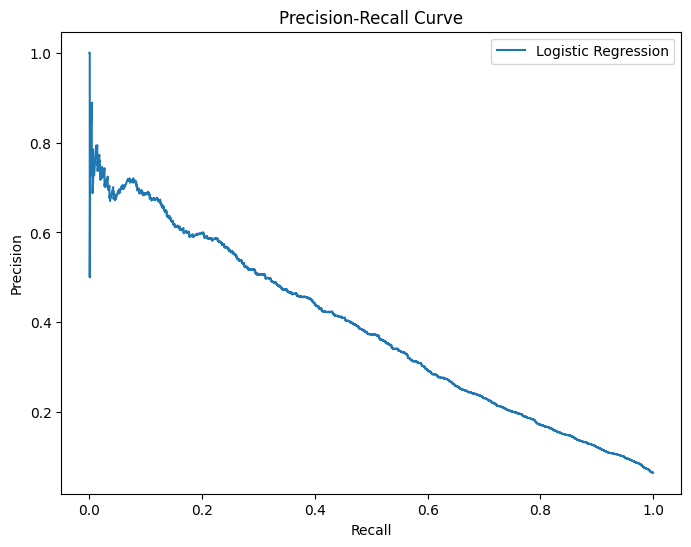

In [23]:
# Auc-PR Curve representada
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_log)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Logistic Regression')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


The Logistic Regression baseline exhibits a steep decline in precision as recall increases. Although the model performs adequately at lower recall levels, its predictive capability deteriorates more rapidly when attempting to capture a larger number of default cases. This model seems to struggle to maintain precision for the minority class.

### Baseline Model: Feature Importance

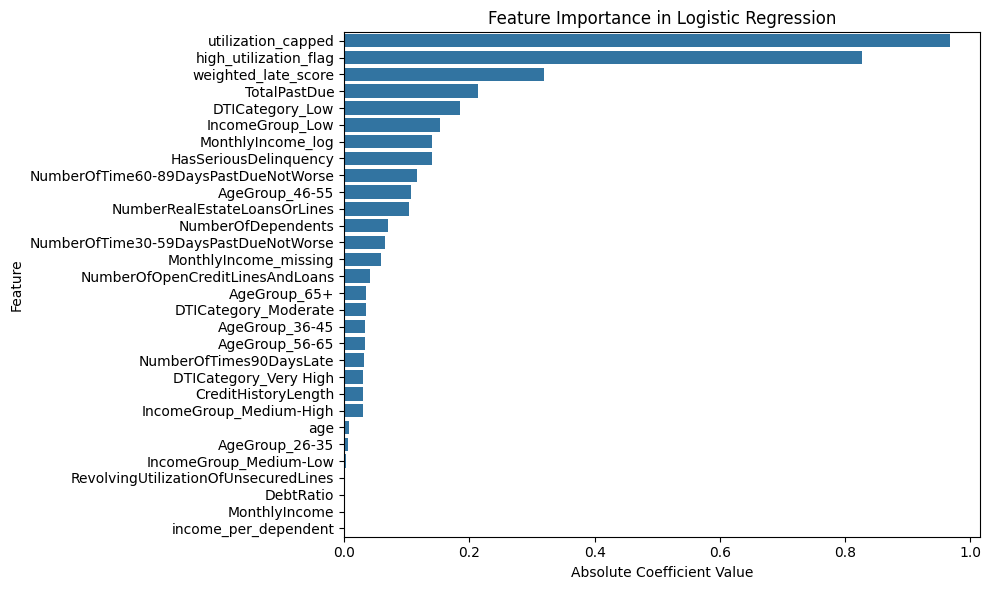

In [24]:
# Importance of Features
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(weighted_lr_model.coef_[0])
}).sort_values(by='Importance', ascending=False)    
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance in Logistic Regression')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Just for future comparaisons, we check the value importance and the AUC-PR value of the model.

## 🔬 Final Model: XGBoost 

After establishing a baseline with Logistic Regression, several ensemble-based models were evaluated, including Random Forest, LightGBM, CatBoost, and XGBoost. Following multiple experiments and comparative evaluations, XGBoost was selected as the final model due to its superior predictive performance and its ability to effectively capture complex non-linear patterns within the credit risk dataset.

In [25]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,       
    gamma=1
)

xgb_model.fit(X_train, y_train)
y_proba_xgb_2 = xgb_model.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred_xgb_2 = (y_proba_xgb_2 >= threshold).astype(int)
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb_2))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     27996
           1       0.77      0.32      0.46      1948

    accuracy                           0.95     29944
   macro avg       0.86      0.66      0.72     29944
weighted avg       0.94      0.95      0.94     29944



In [26]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from sklearn.metrics import make_scorer, f1_score

f1_class1 = make_scorer(f1_score, pos_label=1)

xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42, 
    class_weight={0: 1, 1: 14}
)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.5, 1, 2],
    'scale_pos_weight': [1, 3, 5, 10]  
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=40,
    scoring=f1_class1,
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters:
{'subsample': 1.0, 'scale_pos_weight': 3, 'n_estimators': 100, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.6}


### XGBoost: Threshold Optimization

Similarly to the baseline model, threshold optimization was also applied to the ensemble models in order to address the strong class imbalance present in the dataset. Instead of using the default classification cutoff, the decision threshold was adjusted to maximize the F1-Score for the minority class while maintaining a minimum recall level, ensuring that a sufficient proportion of potential default cases was correctly identified.

In [27]:
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score

best_xgb = random_search.best_estimator_
y_proba = best_xgb.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.01, 0.99, 100)

best_threshold = 0.5
best_f1 = 0
target_recall = 0.65

results = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    
    recall    = recall_score(y_test, y_pred, zero_division=0)
    precision = precision_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    
    results.append((t, recall, precision, f1))
    
    if recall >= target_recall and f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Mejor threshold (recall >= {target_recall}): {best_threshold:.4f}")
print(f"F1-Score clase 1: {best_f1:.4f}")

y_pred_final = (y_proba >= best_threshold).astype(int)

print("\nXGBoost Classification Report (Optimizado por F1):")
print(classification_report(y_test, y_pred_final))

Mejor threshold (recall >= 0.65): 0.3268
F1-Score clase 1: 0.4967

XGBoost Classification Report (Optimizado por F1):
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     27996
           1       0.40      0.66      0.50      1948

    accuracy                           0.91     29944
   macro avg       0.69      0.79      0.72     29944
weighted avg       0.94      0.91      0.92     29944



The optimized XGBoost model achieved a recall of 0.66 for the default class while maintaining an F1-Score close to 0.50 after threshold tuning. Although precision for defaulters remains moderate, the model successfully captures a large proportion of risky clients, which is particularly important in credit risk prediction tasks where missing potential defaults can be significantly more costly than generating additional false positives.

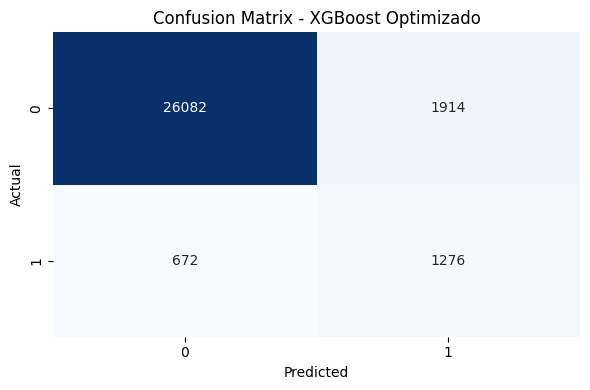

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - XGBoost Optimizado')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### AUC-PR Score

In [29]:
# AUC-PR Score
auc_pr_xgb = roc_auc_score(y_test, y_proba)
print(f"AUC-PR Score: {auc_pr_xgb:.4f}")

AUC-PR Score: 0.9021


Additionally, the model achieved an AUC-PR score of 0.9021, indicating a strong ability to distinguish default cases within a highly imbalanced dataset. Since Precision-Recall metrics place greater emphasis on the minority class, this result further confirms the model’s effectiveness in identifying high-risk clients while maintaining a reasonable balance between precision and recall.

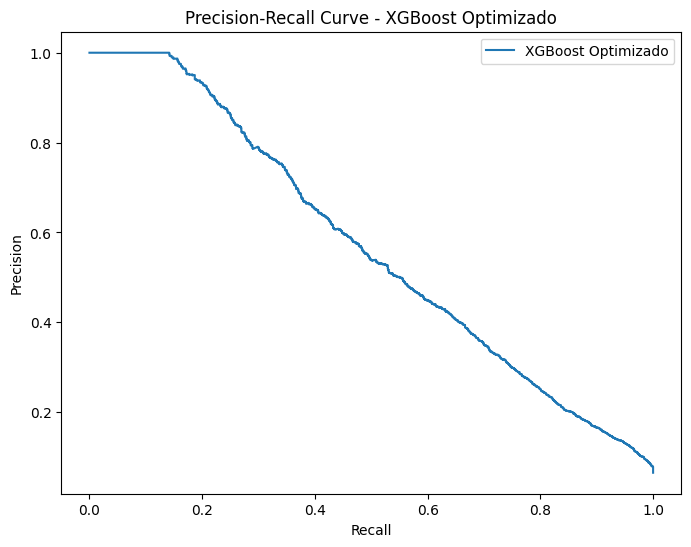

In [30]:
# AUC-PR Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='XGBoost Optimizado')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost Optimizado')
plt.legend()
plt.show()

The Precision-Recall curve of the optimized XGBoost model shows a consistently stronger balance between precision and recall across different classification thresholds. The curve remains relatively high during a large portion of the recall range, indicating that the model is capable of identifying a significant proportion of default cases while preserving reasonable precision. This behavior reflects a robust discriminatory capacity for the minority class, which is especially important in imbalanced credit risk problems.

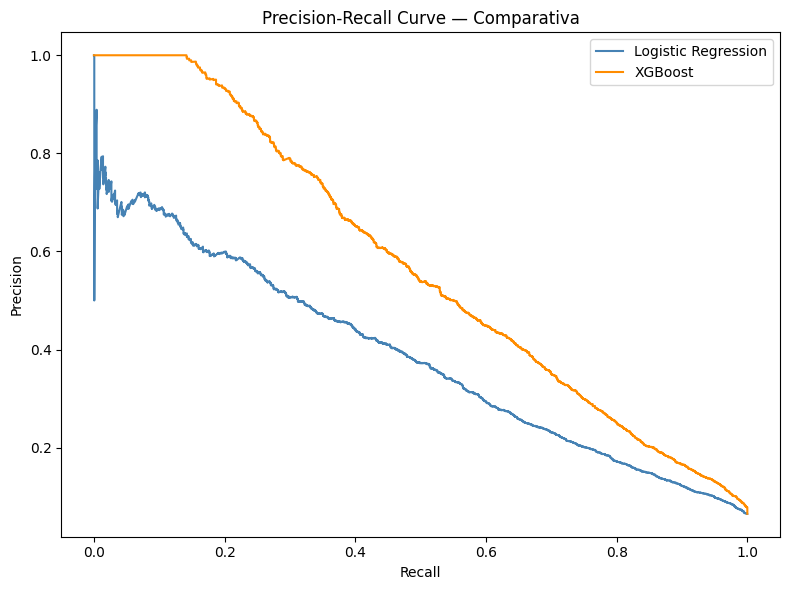

In [41]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression
precision_log, recall_log, _ = precision_recall_curve(y_test, y_pred_proba_log)
ax.plot(recall_log, precision_log, color='steelblue', label='Logistic Regression')

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_proba)
ax.plot(recall_xgb, precision_xgb, color='darkorange', label='XGBoost')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Comparativa')
ax.legend()

plt.tight_layout()
plt.savefig("pr_curves_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()

### 📊 Modelling Results

The dataset exhibits a significant class imbalance (93% no-default / 7% default), making the detection of the minority class (default) the central challenge of this project. Global accuracy is misleading in this context — a model that always predicts "no default" would achieve 93% accuracy without providing any real value — so optimization focused on the **F1-Score for class 1**, which balances precision and recall equally, subject to a **minimum recall of 65%** to ensure at least two-thirds of actual defaults are caught.

---

#### XGBoost *(selected model)*

| Metric   | Class 0 (no-default) | Class 1 (default) |
|-----------|----------------------|-------------------|
| Precision | 0.97                 | 0.40              |
| Recall    | 0.93                 | 0.66              |
| F1-Score  | 0.95                 | 0.50              |
| **AUC-PR Score** | **0.9021** | **Threshold: 0.3268** |

XGBoost required lowering the decision threshold to **0.3268** (well below the default 0.5) to reach the target recall. This reflects the fact that a model trained on imbalanced data tends to assign low probabilities to the minority class, making it necessary to reduce the classification threshold in order to capture more actual defaults.

With this adjustment, the model detects **66% of real defaults** (recall), though at the cost of a 40% precision: out of every 10 clients flagged as default, 6 are genuine and 4 are false alarms. This trade-off is common and generally acceptable in credit risk settings, where the cost of missing a default far outweighs the cost of investigating a false alarm. The **F1-Score of 0.50** reflects this balance in a highly challenging scenario.

---

#### Logistic Regression *(baseline)*

| Metric   | Class 0 (no-default) | Class 1 (default) |
|-----------|----------------------|-------------------|
| Precision | 0.97                 | 0.26              |
| Recall    | 0.87                 | 0.65              |
| F1-Score  | 0.92                 | 0.37              |
| **AUC-PR Score** | **0.8508** | **Threshold: 0.5800** |

Logistic Regression achieves a similar recall (0.65 vs 0.66) but with notably lower precision: only **26% of clients flagged as default actually are**, compared to 40% for XGBoost. This means the logistic model generates **twice as many false alarms** to detect roughly the same number of real defaults, making it considerably less efficient.

Its F1-Score of **0.37** confirms this weaker discriminative power: while both models meet the minimum recall requirement, Logistic Regression sacrifices too much precision to get there.

---

#### Comparison & Conclusion

| Model               | Threshold | Precision (c1) | Recall (c1) | F1 (c1) | Accuracy |
|----------------------|-----------|----------------|-------------|---------|----------|
| **XGBoost**          | 0.3268    | **0.40**       | **0.66**    | **0.50**| **0.91** |
| Logistic Regression  | 0.5800    | 0.26           | 0.65        | 0.37    | 0.86     |

XGBoost outperforms the baseline across all relevant metrics. The most significant gap lies in **precision** (+14 percentage points), which translates directly into an F1-Score **35% higher** (0.50 vs 0.37). Both models reach a similar recall, but XGBoost does so while generating far fewer false alarms and with an overall accuracy 5 points higher.

In a credit scoring context, this difference has clear practical implications: XGBoost enables action on a cleaner list of at-risk clients, reducing the operational costs of manual review and improving the experience of clients who would not have defaulted. For all these reasons, **XGBoost is selected as the final model for this project**.

## ⚙️ Feature Importance

To ensure transparency of the final model (XGBoost), three complementary interpretability techniques were applied: **Feature Importance (Gain)** for a global view of each variable's predictive power, **SHAP** to understand the directional impact of each feature on predictions, and **LIME** for instance-level individual explanations.

### 📈 Feature Importance (Gain)

For the credit default classification model, Feature Importance based on Gain was used to identify which variables contributed most to the model’s predictive performance. This method measures how much each feature improves the decision-making process across the model’s trees, providing a clear overview of the main drivers behind default risk predictions. It helped prioritize the most influential financial and behavioral variables in the analysis

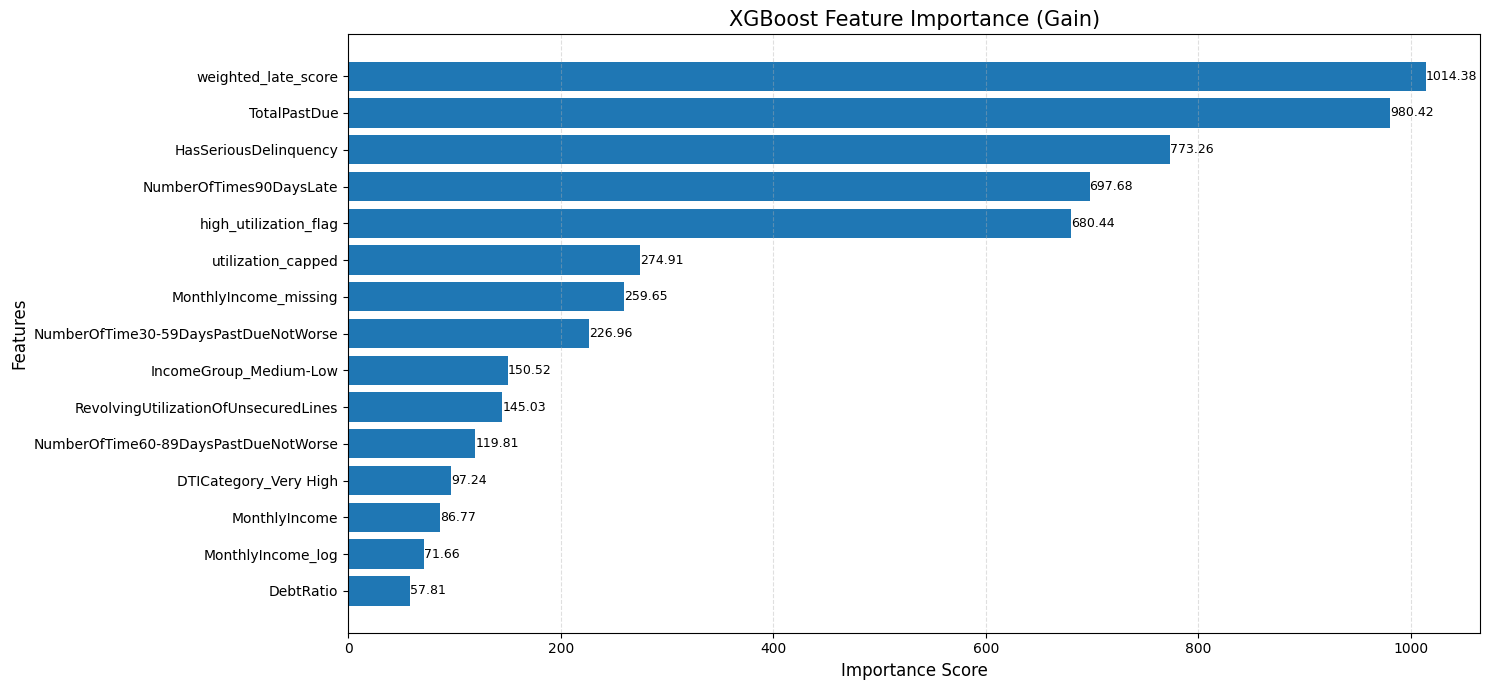

,Feature,Importance
3,DebtRatio,57.811691
11,MonthlyIncome_log,71.664619
4,MonthlyIncome,86.773766
29,DTICategory_Very High,97.239731
8,NumberOfTime60-89DaysPastDueNotWorse,119.810600
0,RevolvingUtilizationOfUnsecuredLines,145.033981
26,IncomeGroup_Medium-Low,150.518768
2,NumberOfTime30-59DaysPastDueNotWorse,226.956299
10,MonthlyIncome_missing,259.647430
13,utilization_capped,274.914856


In [31]:
def plot_feature_importance(
    model,
    importance_type='gain',
    top_n=None,
    figsize=(10, 6),
    title='Feature Importance'
):
    """
    Plot XGBoost feature importance in a clean and reusable way.

    Parameters
    ----------
    model : trained XGBoost model
        Example: best_xgb

    importance_type : str, default='gain'
        Type of importance:
        - 'weight'
        - 'gain'
        - 'cover'
        - 'total_gain'
        - 'total_cover'

    top_n : int or None, default=None
        Number of top features to display.
        If None, all features are shown.

    figsize : tuple, default=(10, 6)
        Figure size.

    title : str, default='Feature Importance'
        Plot title.
    """

    # Extract feature importance
    importance = model.get_booster().get_score(
        importance_type=importance_type
    )

    # Convert to DataFrame
    importance_df = pd.DataFrame({
        'Feature': list(importance.keys()),
        'Importance': list(importance.values())
    })

    # Sort values
    importance_df = (
        importance_df
        .sort_values(by='Importance', ascending=False)
    )

    # Keep only top N features
    if top_n is not None:
        importance_df = importance_df.head(top_n)

    # Reverse for horizontal bar plot
    importance_df = importance_df[::-1]

    # Plot
    plt.figure(figsize=figsize)

    bars = plt.barh(
        importance_df['Feature'],
        importance_df['Importance']
    )

    # Add values at the end of bars
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f'{width:.2f}',
            va='center',
            fontsize=9
        )

    plt.title(f'{title} ({importance_type.capitalize()})', fontsize=15)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Features', fontsize=12)

    plt.grid(axis='x', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

    return importance_df


plot_feature_importance(
    model=best_xgb,
    importance_type='gain',
    top_n=15,
    figsize=(15, 7),
    title='XGBoost Feature Importance'
)

The gain-based importance chart reflects how much each variable contributes to reducing impurity across the model's trees. The two dominant features are `weighted_late_score` and `TotalPastDue`, with notably higher importance than the rest — roughly twice that of the third most relevant variable — indicating that the model relies heavily on the client's late payment history. Following these are `HasSeriousDelinquency` and `NumberOfTimes90DaysLate`, reinforcing the same signal: severe and repeated delinquencies are the most robust predictor of default. At a secondary importance level, `high_utilization_flag` and `utilization_capped` indicate that credit utilization also contributes meaningful information, though considerably below the delinquency variables. The remaining features — income, debt-to-income ratio, number of open lines — contribute only marginally in terms of gain.

### 🔬 LIME (Local Explanation)


LIME (Local Interpretable Model-agnostic Explanations) was applied to provide local interpretability for individual credit default predictions. By approximating the model’s behavior around a specific case, LIME highlights which features influenced a particular approval or default prediction the most. This approach improves transparency and supports more understandable decision-making in risk assessment scenarios.

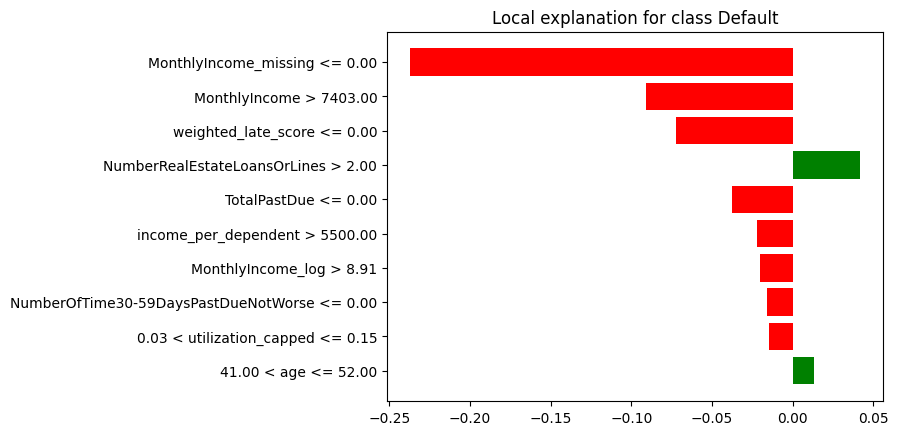

In [32]:
from lime import lime_tabular

explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=['No Default', 'Default'],
    mode='classification'
)

i = 0

exp = explainer_lime.explain_instance(
    X_test.iloc[i].values,
    lambda x: xgb_model.predict_proba(x),
    num_features=10
)

fig = exp.as_pyplot_figure()


The LIME explanation corresponds to a specific instance classified as **Default** and helps understand which factors led the model to that particular decision. The variable with the greatest negative weight (pushing toward default) is `MonthlyIncome_missing <= 0`, confirming that the absence of income data is the single most decisive signal in this case. This is followed by `MonthlyIncome > 7403` and `weighted_late_score <= 0`, which may seem counterintuitive — high income pushing toward default — but is explained by the fact that LIME analyzes local combinations of conditions: in this specific profile, other risk factors outweigh the income level. `TotalPastDue <= 0` and `MonthlyIncome_log > 8.91` also contribute negatively. On the other hand, `high_utilization_flag <= 0` and `NumberRealEstateLoansOrLines > 2` act as slight risk-mitigating factors for this particular instance.


### 🌐 SHAP (Global & Directional Impact)


SHAP (SHapley Additive exPlanations) was used to achieve both global and local interpretability of the credit risk classification model. Based on cooperative game theory, SHAP quantifies the contribution of each feature to the final prediction, allowing a consistent explanation of default probabilities across observations. This method provided deeper insights into how variables interact and influence model outcomes, enhancing trust and explainability in the predictive system.

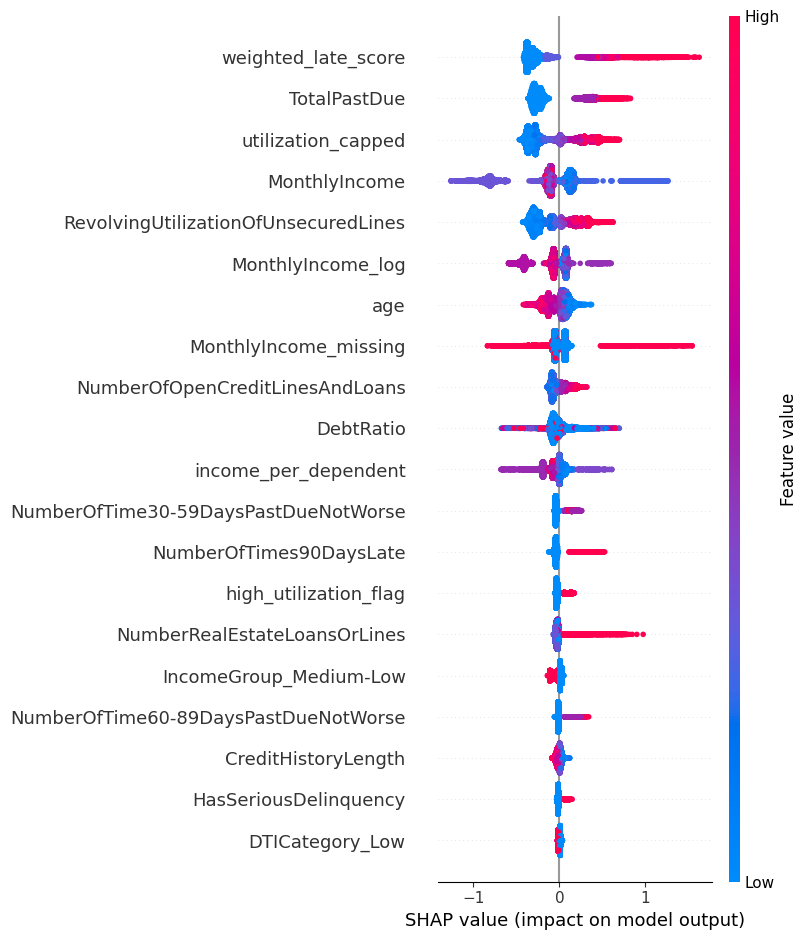

In [33]:
# Shap
import shap
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

The beeswarm plot ranks all features by their mean absolute SHAP contribution and reveals both the magnitude and direction of their effect on default probability. The overall picture is consistent with the gain-based importance analysis: **payment history variables dominate overwhelmingly**, with `weighted_late_score`, `TotalPastDue`, and the 90-day and 30-59 day delinquency counts all generating the largest positive SHAP shifts when their values are high (red). The model has learned that any meaningful history of late or missed payments is the clearest indicator of future default.

A second tier of features — `utilization_capped`, `RevolvingUtilizationOfUnsecuredLines`, and `high_utilization_flag` — contributes in the expected direction: high credit utilization pushes predictions toward default, though with considerably less force than the delinquency variables. `MonthlyIncome` acts primarily as a protective factor, with high values (red) pulling predictions away from default, while `MonthlyIncome_missing` does the opposite: the absence of income data is itself interpreted as a risk signal, producing some of the furthest rightward SHAP values in the plot.

The remaining features — `age`, `DebtRatio`, `CreditHistoryLength`, `NumberOfOpenCreditLinesAndLoans` — show modest, roughly symmetric contributions with no dominant directional pattern, confirming their marginal role in the model's decision process.

In [34]:
# <!-- SHAP analysis complements gain-based importance by adding the **direction** of each variable's effect on the probability of default. `weighted_late_score` again leads: high values (in red) are associated with positive SHAP values, pushing predictions toward default, while low values reduce risk. `TotalPastDue` shows a similar pattern with less dispersion, and `utilization_capped` also impacts positively when elevated.

# A particularly relevant finding is the behavior of `MonthlyIncome_missing`: the absence of income data generates strongly positive SHAP values (higher default risk), suggesting that missing income information is itself a risk signal the model has learned to exploit. Conversely, high values of `MonthlyIncome` act as a protective factor, pushing predictions toward no-default. The variable `age` shows a moderate protective effect for older clients, consistent with the credit risk literature. -->

Individual effect of Montly Income

In [35]:
# shap_array = shap_values.values if hasattr(shap_values, "values") else shap_values
# fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# axes = axes.flatten()
# features = ["HasSeriousDelinquency", "weighted_late_score", "NumberOfTimes90DaysLate", "TotalPastDue"]

# for i, feature in enumerate(features):
#     feature_vals = X_test[feature].values
#     shap_vals = shap_array[:, i]

#     # Normalize feature values to [0, 1] for colormap
#     vmin, vmax = np.percentile(feature_vals, [5, 95])
#     norm = plt.Normalize(vmin=vmin, vmax=vmax)
#     colors = plt.cm.coolwarm(norm(feature_vals))

#     sc = axes[i].scatter(feature_vals, shap_vals, c=feature_vals,
#                          cmap="coolwarm", alpha=0.3, vmin=vmin, vmax=vmax)
#     plt.colorbar(sc, ax=axes[i], label=feature)
#     axes[i].set_title(feature)
#     axes[i].set_xlabel(feature)
#     axes[i].set_ylabel("SHAP value")
#     axes[i].axhline(0, color="black", linewidth=0.8, linestyle="--")

# plt.tight_layout()
# plt.show()

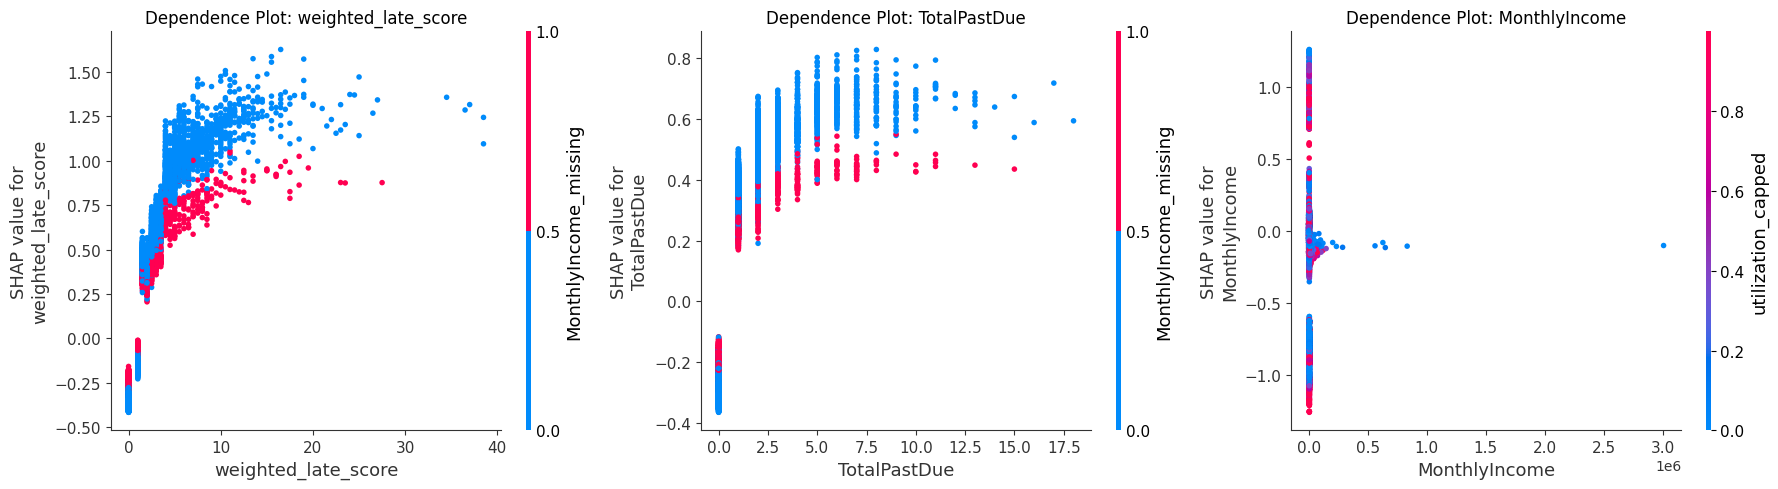

In [38]:
import shap
import matplotlib.pyplot as plt

top_features = ["weighted_late_score", "TotalPastDue", "MonthlyIncome"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, top_features):
    shap.dependence_plot(
        feature,
        shap_values,
        X_test,
        interaction_index="auto",
        ax=ax,
        show=False
    )
    ax.set_title(f"Dependence Plot: {feature}", fontsize=12)

plt.tight_layout()
plt.savefig("shap_dependence_plots.png", dpi=150, bbox_inches="tight")
plt.show()

The plots below show how each feature's value maps to its SHAP contribution toward default prediction (positive = pushes toward default, negative = pushes away).

**`HasSeriousDelinquency`** — The clearest binary signal in the model. Clients with no serious delinquency (value = 0, blue) consistently receive large negative SHAP values, strongly reducing default risk. Those with at least one serious delinquency (value = 1, red) shift to positive SHAP values, significantly increasing it. The separation is sharp and almost deterministic.

**`weighted_late_score`** — Shows a non-linear relationship. The vast majority of clients cluster near zero with mixed but moderate SHAP values. As the score increases beyond ~5, SHAP values trend positive and the color shifts to red, confirming that a higher weighted late score progressively drives up default probability. The wide spread at low values suggests this feature interacts with other variables.

**`NumberOfTimes90DaysLate`** — Displays a clear two-band structure: clients with zero 90-day late events (blue) fall below the SHAP = 0 line, acting as a protective signal. Any non-zero count immediately flips the contribution positive, with SHAP values around +0.10–0.20 regardless of the exact count — suggesting the model reacts strongly to the *presence* of severe delinquency more than its frequency.

**`TotalPastDue`** — The most visually complex plot. A value of 0 produces a wide vertical spread of both positive and negative SHAP values, indicating that clients with no past due balance are heterogeneous in risk. As `TotalPastDue` increases (redder points), SHAP values trend positive, but there is also a notable cluster of high-value clients with negative SHAP — suggesting the model partially discounts very high past due amounts, possibly due to interaction effects with income or utilization features.

## 🔍 Model Interpretability

All three techniques converge on a clear conclusion: the client's historical payment behavior is, by far, the most decisive factor in predicting default.

All three interpretability techniques are mutually consistent and point to the same explanatory core: **late payment history and accumulated delinquency are the dominant predictors of default**, followed at a distance by credit utilization level and the availability of income information. This coherence between global and local methods reinforces confidence in the model and facilitates its potential use in regulated environments where the explainability of credit decisions is a requirement.